In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Part 1 — Random Walk in One Dimension

N particles in total, walk T setps.

Each particle moves:
- +1 with probability 1/2
- -1 with probability 1/2

All particles start at x = 0.


In [ ]:
def random_walk_1d(N, T, boundary_condition=None, L=None):
    positions = np.zeros((T+1, N))

    for t in range(1, T+1):
        steps = np.random.choice([-1, 1], size=N)
        new_pos = positions[t-1] + steps

        if boundary_condition is not None:
            if L is not None:
                new_pos = boundary_condition(new_pos, L)
            else:
                new_pos = boundary_condition(new_pos)

        positions[t] = new_pos

    return positions


Computing the mean squared displacement:

In [ ]:
def mean_squared_displacement_1d(positions):
  return np.mean(positions**2, axis=1)

Stimulating with some N and T:

In [ ]:
N = 1000
T = 500
positions_1d = random_walk_1d(N, T)
msd_1d = mean_squared_displacement_1d(positions_1d)

### Plot 1 — Single Particle Trajectory

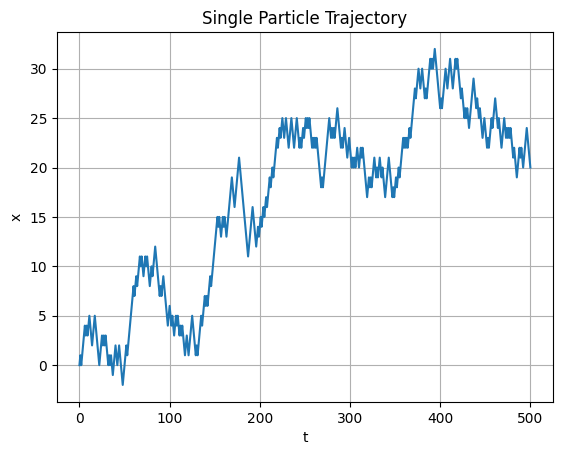

In [ ]:
plt.figure()
plt.plot(range(T+1), positions_1d[:,0])
plt.xlabel("t")
plt.ylabel("x")
plt.title("Single Particle Trajectory")
plt.grid()
plt.show()

### Plot 2 — Multiple Trajectories

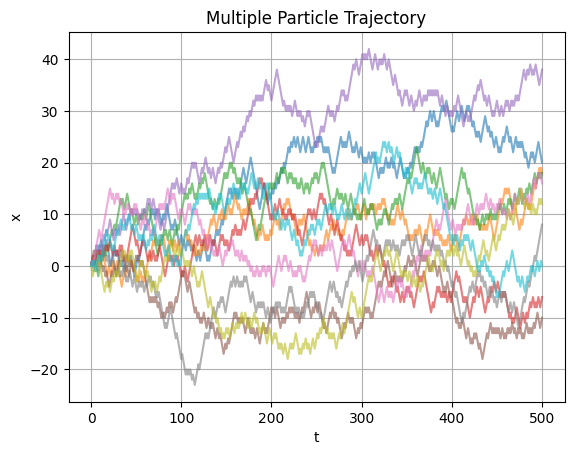

In [ ]:
plt.figure()
for i in range(10):
  plt.plot(range(T+1), positions_1d[:,i],alpha=0.6)
plt.xlabel("t")
plt.ylabel("x")
plt.title("Multiple Particle Trajectory")
plt.grid()
plt.show()

### Plot 3 — Mean Squared Displacement

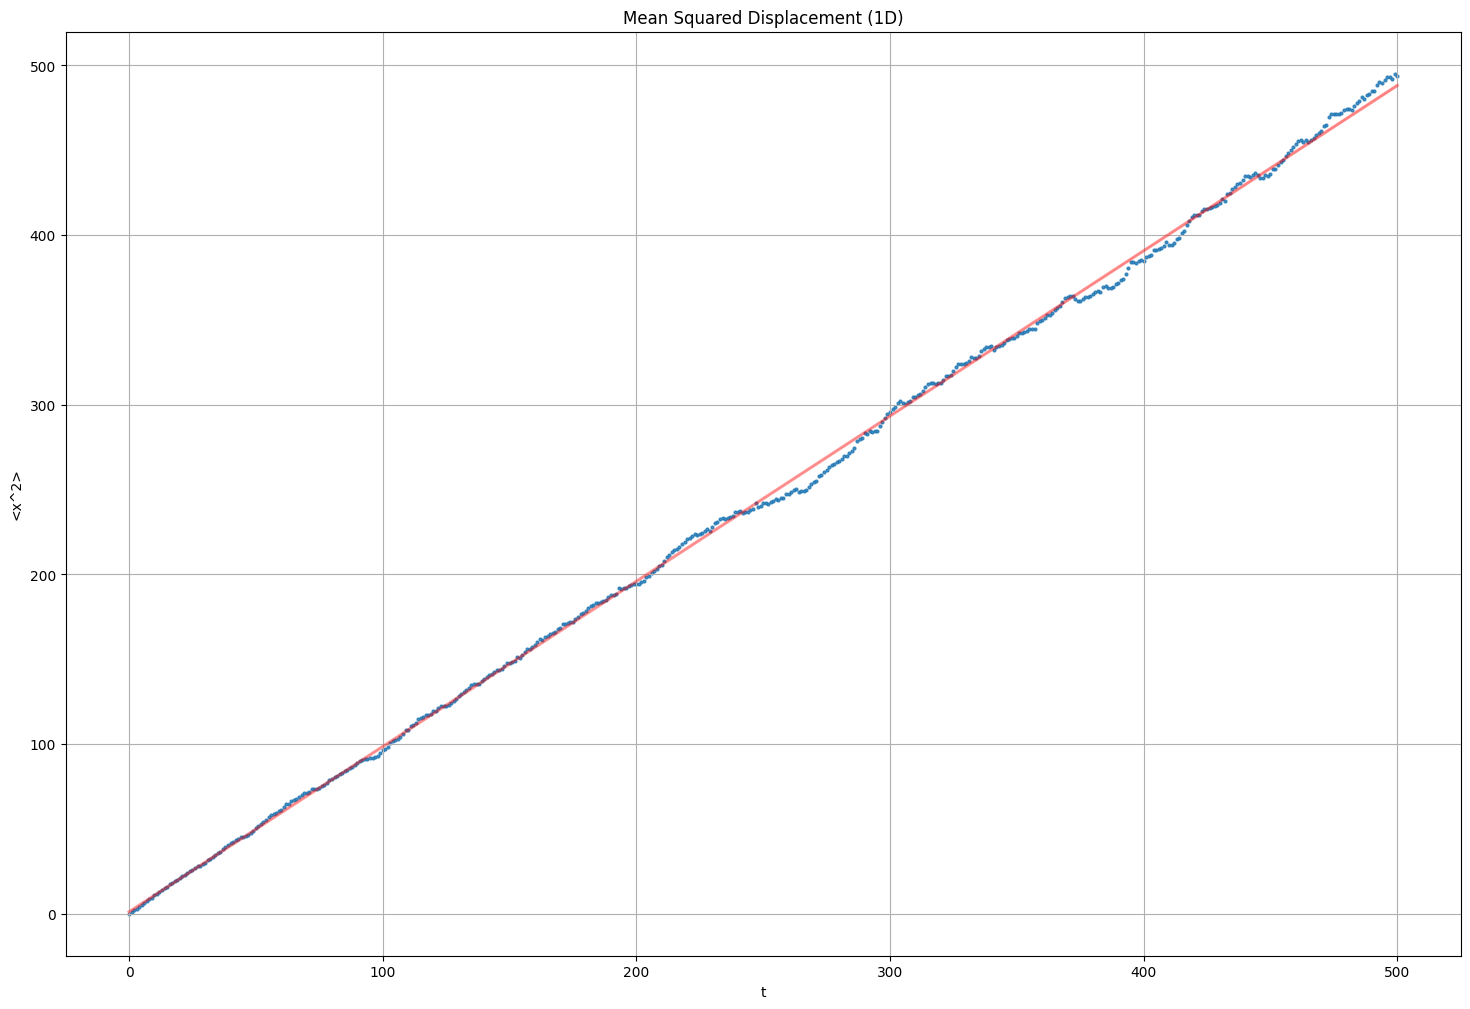

In [ ]:
plt.figure(figsize=(18,12))
sns.regplot(
    x=np.arange(T+1),
    y=msd_1d,
    scatter_kws={"s":4,"alpha":0.8},
    line_kws={'color':'red',"alpha":0.4}
)
plt.xlabel("t")
plt.ylabel("<x^2>")
plt.title("Mean Squared Displacement (1D)")
plt.grid()
plt.show()

### Estimation of Diffusion Coefficient

Using:

$$
\langle x^2 \rangle = 2Dt
$$

In [ ]:
t=np.arange(T+1)
slope,_=np.polyfit(t,msd_1d,1)
D_1d = slope/2
print("Slope:", slope)
print("Estimated D:", D_1d)

Slope: 0.9741067782522608
Estimated D: 0.4870533891261304


## Part 2 — Diffusion in Two Dimensions

N particles in total, walk T setps.

Each particle moves:
- right, left, up, down (probability 1/4 each)

Each particle has coordinates
(x, y)

In [ ]:
def random_walk_2d(N, T, L=None, boundary_condition=None, step_size=1):
    x = np.zeros((T+1, N))
    y = np.zeros((T+1, N))

    for t in range(1, T+1):
        directions = np.random.choice([0, 1, 2, 3], size=N)

        dx = np.zeros(N)
        dy = np.zeros(N)

        dx[directions == 0] = step_size
        dx[directions == 1] = -step_size
        dy[directions == 2] = step_size
        dy[directions == 3] = -step_size

        new_x = x[t-1] + dx
        new_y = y[t-1] + dy

        if boundary_condition is not None:
            if L is None:
                raise ValueError("boundary_condition is provided but L is None")
            new_x, new_y = boundary_condition(new_x, new_y, L)

        x[t] = new_x
        y[t] = new_y

    return x, y

Computing the mean squared displacement in 2D:

In [ ]:
def mean_squared_displacement_2d(x,y):
  return np.mean(x**2+y**2, axis=1)

Stimulating with some N and T:

In [ ]:
x,y = random_walk_2d(N,T)
msd_2d = mean_squared_displacement_2d(x,y)

### Plot 4 — 2D Trajectories

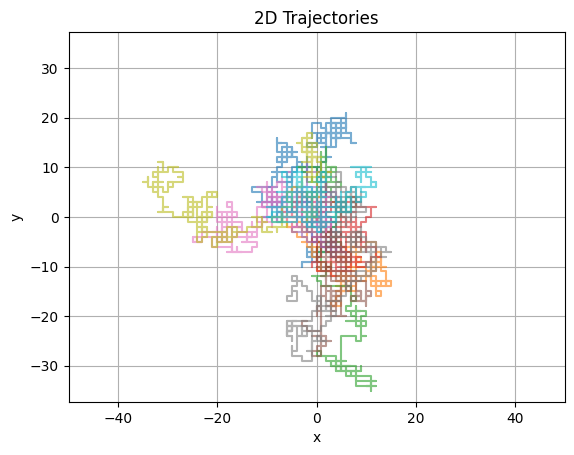

In [ ]:
plt.figure()
for i in range(10):
    plt.plot(x[:, i], y[:, i], alpha=0.6)

plt.axis("equal")
plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Trajectories")
plt.grid()
plt.show()

In [ ]:
def distribution_plot_3d(x_T, y_T, bins=20):
  H, xedges, yedges = np.histogram2d(x_T, y_T, bins=bins, density=True)
  x_centers = (xedges[:-1]+xedges[1:])/2
  y_centers = (yedges[:-1]+yedges[1:])/2
  X = []
  Y = []
  Z = []

  for i in range(len(y_centers)):
      row_x = []
      row_y = []
      row_z = []
      for j in range(len(x_centers)):
          row_x.append(x_centers[j])
          row_y.append(y_centers[i])
          row_z.append(H[i, j])
      X.append(row_x)
      Y.append(row_y)
      Z.append(row_z)

  X = np.array(X)
  Y = np.array(Y)
  Z = np.array(Z)

  surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', antialiased=True)
  ax.set_xlabel('x')
  ax.set_ylabel('y')
  ax.set_zlabel('Density')
  ax.view_init(elev=30, azim=45)



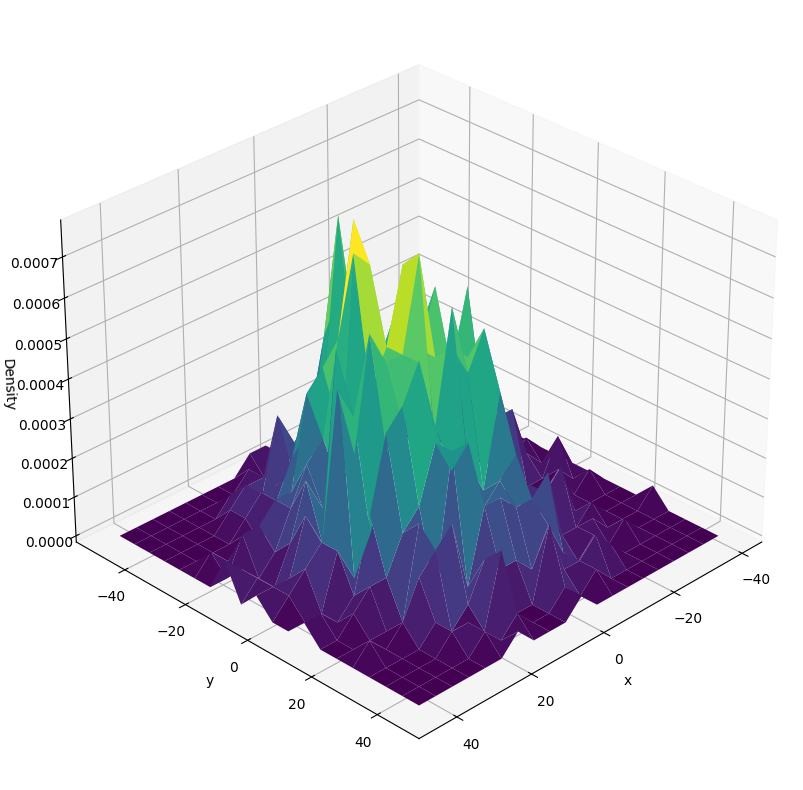

In [ ]:
x_T = x[-1]
y_T = y[-1]
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
distribution_plot_3d(x_T,y_T)
plt.show()

### Plot 5 — Mean Squared Displacement

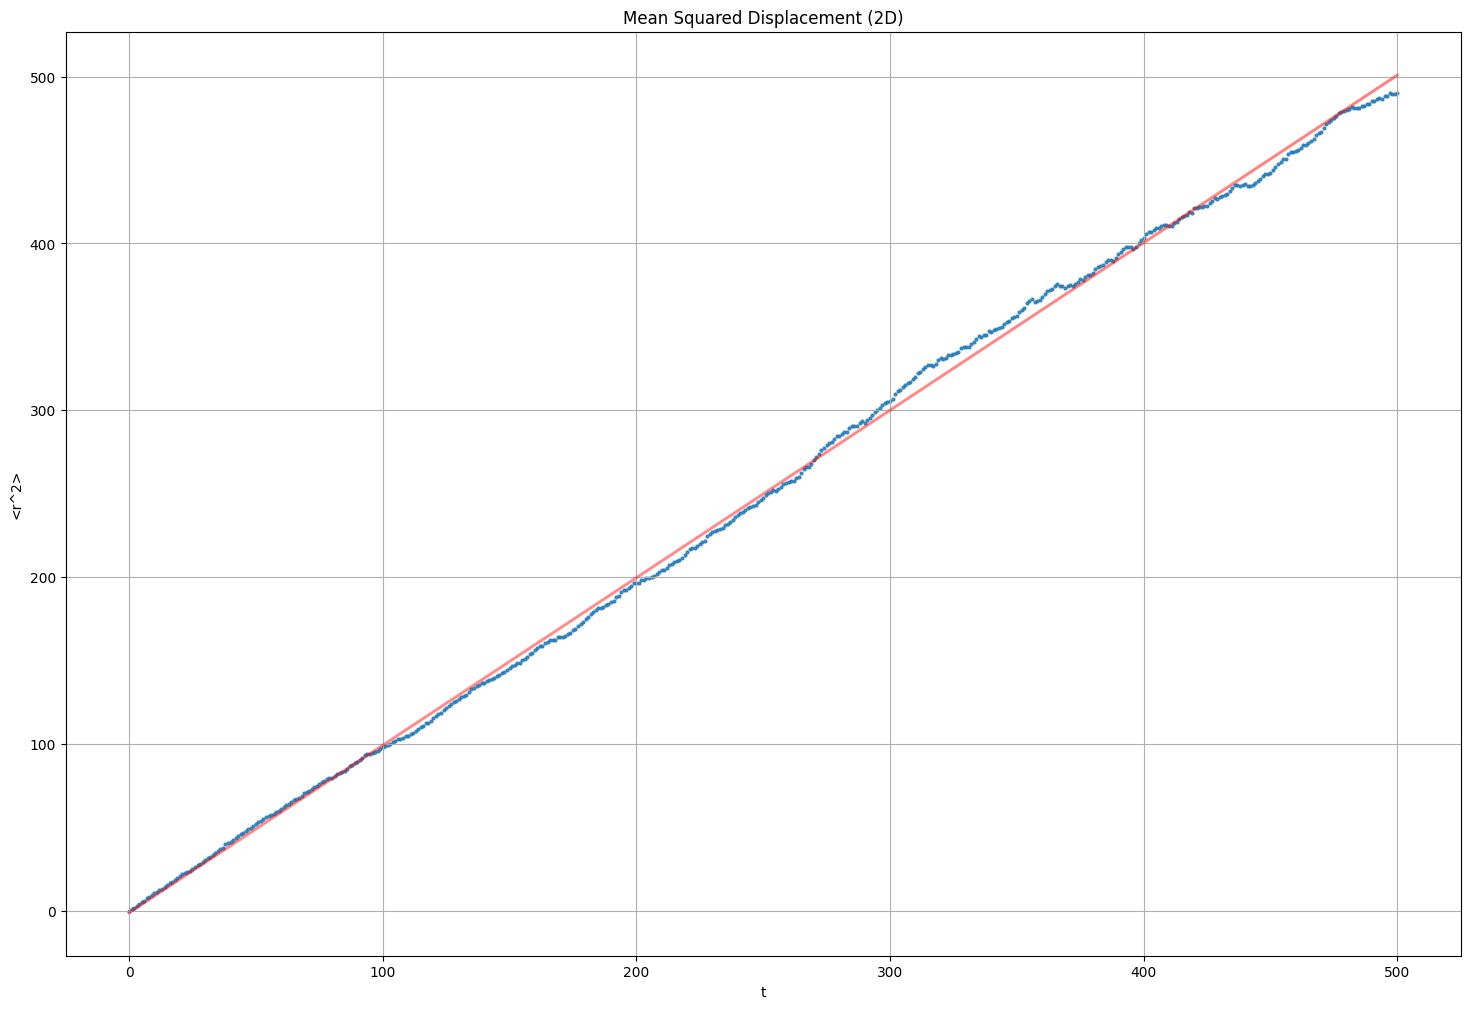

In [ ]:
plt.figure(figsize=(18,12))
sns.regplot(
    x=np.arange(T+1),
    y=msd_2d,
    scatter_kws={"s":4,"alpha":0.8},
    line_kws={'color':'red',"alpha":0.4}
)
plt.xlabel("t")
plt.ylabel("<r^2>")
plt.title("Mean Squared Displacement (2D)")
plt.grid()
plt.show()

In [ ]:
t=np.arange(T+1)
slope,_=np.polyfit(t,msd_2d,1)
D_2d = slope/4
print("Slope:", slope)
print("Estimated D:", D_2d)

Slope: 1.0038111067108815
Estimated D: 0.25095277667772037


## Part 3 — Influence of Initial Conditions

We test different initial distributions.

In [ ]:
scale = 15
def random_initial_positions(N, scale):
  return np.random.uniform(-scale,scale,size=N)



In [ ]:
positions=np.zeros((T+1,N))
positions[0] = random_initial_positions(N, scale)
for t in range(1,T+1):
  steps = np.random.choice([-1,1],size=N)
  positions[t] = positions[t-1]+steps

### Plot 6 — histogram of particle positions

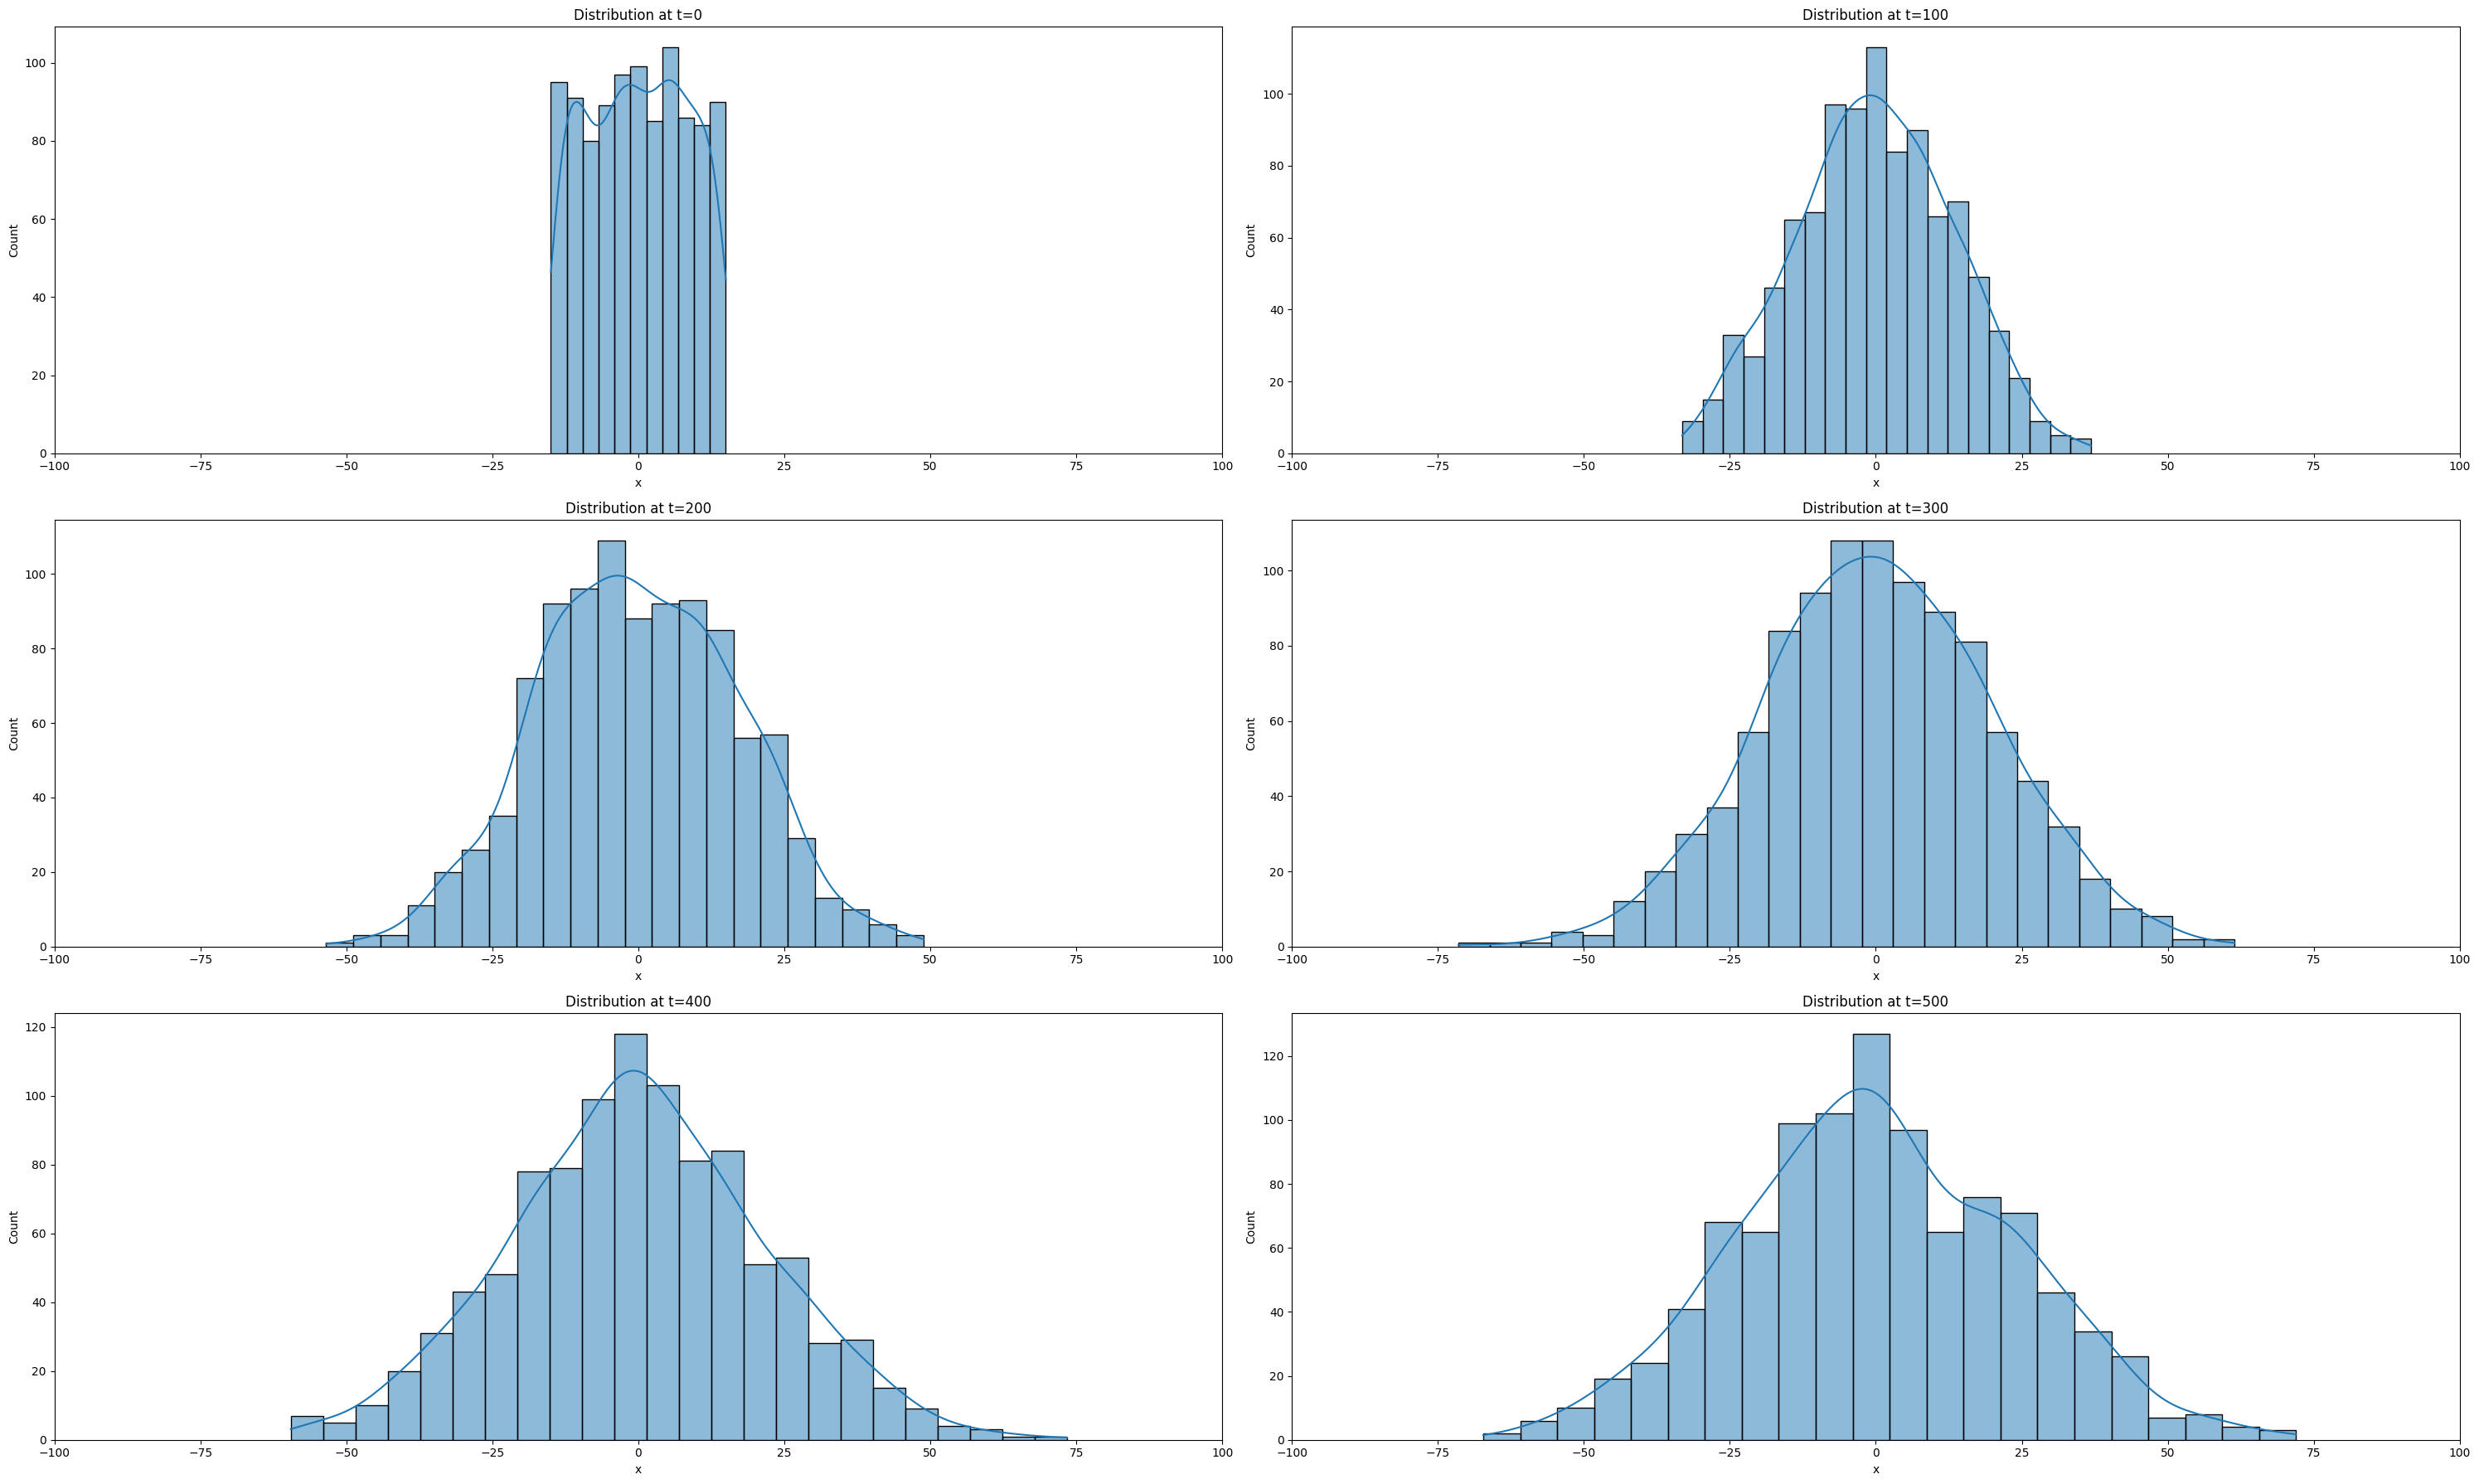

In [ ]:
plt.figure(figsize=(30,18))
time=[0,100,200,300,400,500]
for i in range(1,7):
    plt.subplot(3,2,i)
    sns.histplot(positions[time[i-1]],kde=True)
    plt.title(f"Distribution at t={time[i-1]}")
    plt.xlim(-100, 100)
    plt.xlabel("x")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Part 4 — Boundary Conditions in 1 dimension

(1) reflective boundaries:

In [ ]:
def reflective_boundary(x, L):
  x[x > L] = 2 * L - x[x > L]
  x[x < -L] = -2 * L - x[x < -L]
  return x

In [ ]:
L=50
positions=random_walk_1d(N, T, reflective_boundary, L)


### Plot 7 — histogram of particle positions with reflective boundaries

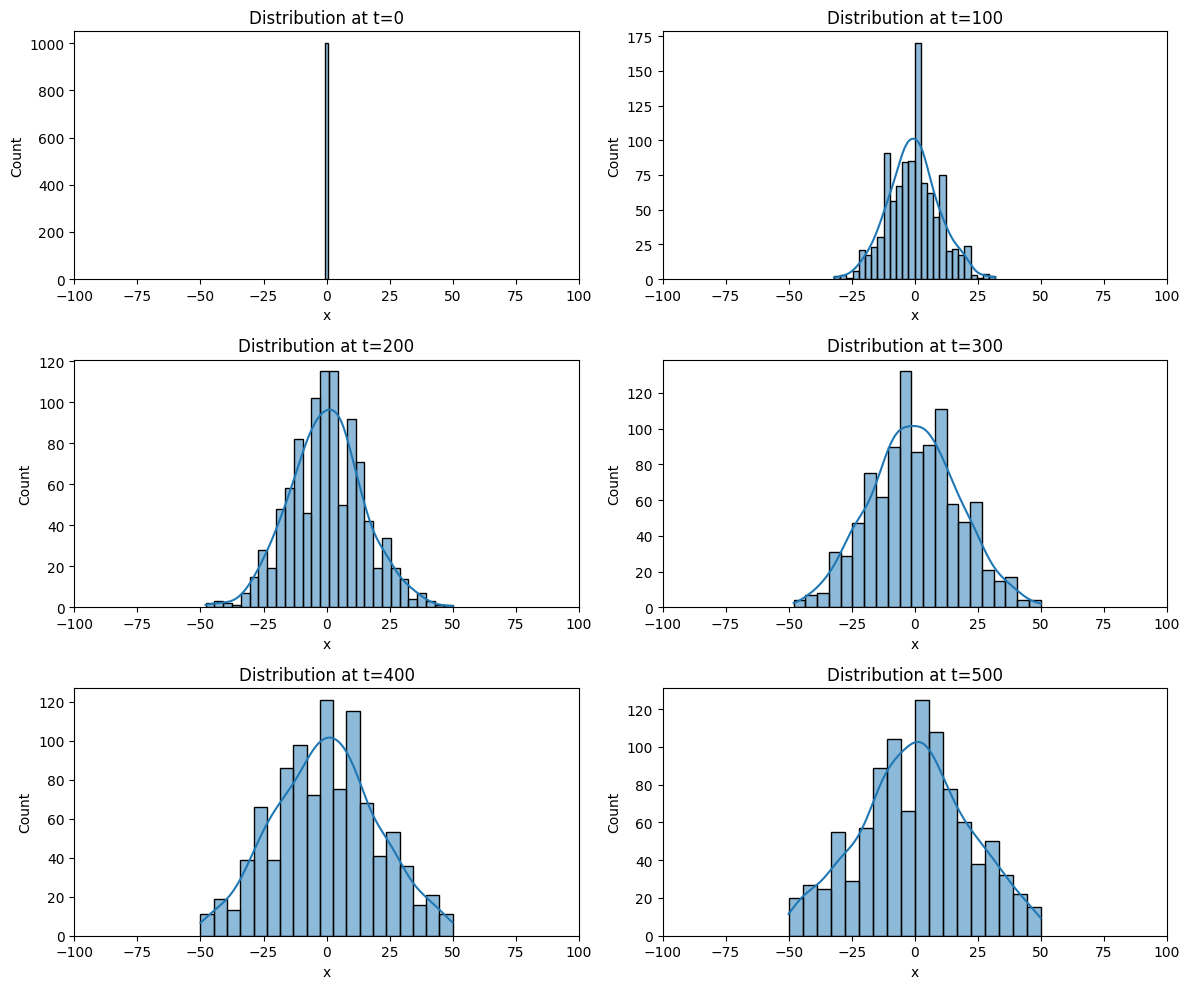

In [ ]:
plt.figure(figsize=(12,10))
time=[0,100,200,300,400,500]
for i in range(1,7):
    plt.subplot(3,2,i)
    sns.histplot(positions[time[i-1]],kde=True)
    plt.title(f"Distribution at t={time[i-1]}")
    plt.xlim(-100, 100)
    plt.xlabel("x")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

(2) Absorbing boundaries:

In [ ]:
def absorbing_boundary(x, L):
    x[x > L] = np.nan
    x[x < -L] = np.nan
    return x

In [ ]:
L=50
positions=random_walk_1d(N, T, absorbing_boundary, L)

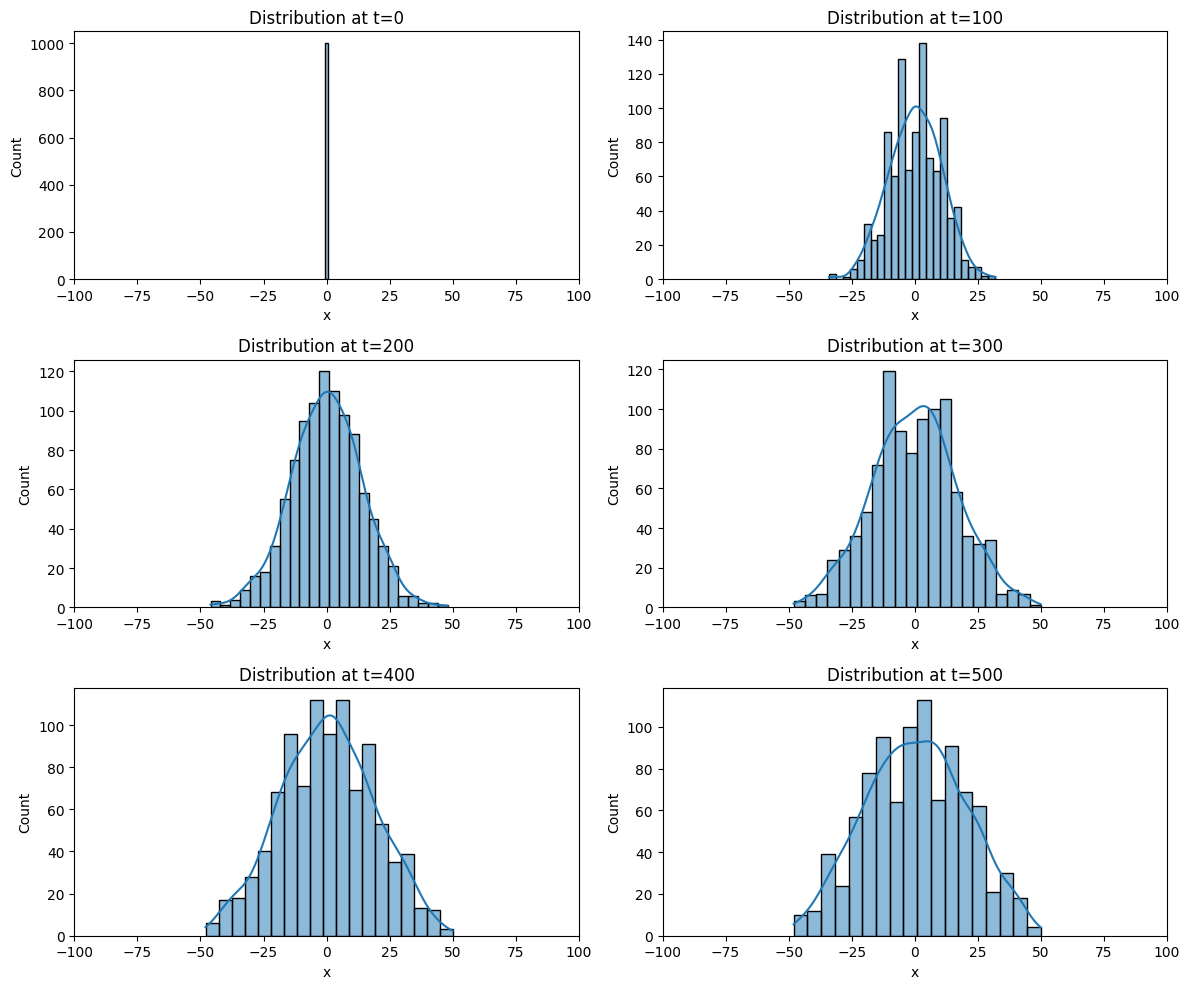

In [ ]:
plt.figure(figsize=(12,10))
time=[0,100,200,300,400,500]
for i in range(1,7):
    plt.subplot(3,2,i)
    sns.histplot(positions[time[i-1]],kde=True)
    plt.title(f"Distribution at t={time[i-1]}")
    plt.xlim(-100, 100)
    plt.xlabel("x")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

Plot 8 — line chart of alive numbers of particles

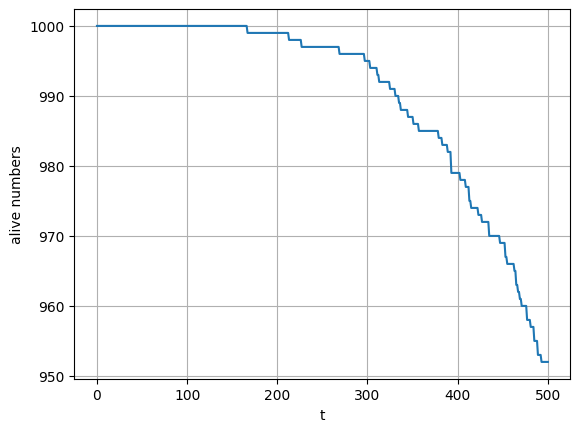

In [ ]:
alives = []
for t in range(0,T+1):
    alive = np.sum(~np.isnan(positions[t]))
    alives.append(alive)
plt.figure()
plt.plot(range(T+1),alives)
plt.xlabel("t")
plt.ylabel("alive numbers")
plt.grid()
plt.show()


(3) Periodic boundaries:

In [ ]:
def periodic_boundary(x, L):
  x[x > L] = x[x > L] - 2 * L
  x[x < -L] = x[x < -L] + 2 * L
  return x

In [ ]:
L=20
positions=random_walk_1d(N, T, periodic_boundary, L)

### Plot 9 — Trajectories of particles with periodic boundaries

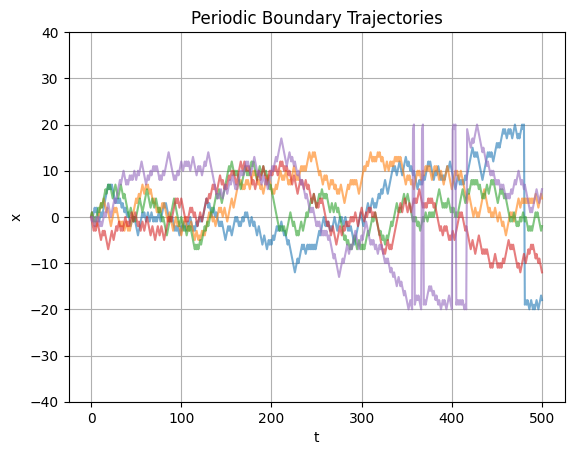

In [ ]:
plt.figure()
for i in range(5):
  plt.plot(range(T+1), positions[:,i], alpha=0.6)
plt.ylim(-40,40)
plt.xlabel("t")
plt.ylabel("x")
plt.title("Periodic Boundary Trajectories")
plt.grid()
plt.show()

## Part 5 — Influence of Initial Conditions in 2D

In [ ]:
def random_initial_positions_2d(N, scale):
  x0 = np.random.uniform(-scale,scale,size=N)
  y0 = np.random.uniform(-scale,scale,size=N)
  return x0, y0

In [ ]:
scale = 5
x_positions=np.zeros((T+1,N))
y_positions=np.zeros((T+1,N))
x0, y0 = random_initial_positions_2d(N, scale)

x_positions[0] = x0
y_positions[0] = y0
for t in range(1,T+1):
    directions = np.random.choice([1,2,3,4],N)

    dx=np.zeros(N)
    dx[directions==1]=1
    dx[directions==2]=-1

    dy=np.zeros(N)
    dy[directions==3]=1
    dy[directions==4]=-1

    x_positions[t] = x_positions[t-1] + dx
    y_positions[t] = y_positions[t-1] + dy


### Plot 10 — histogram of particle positions

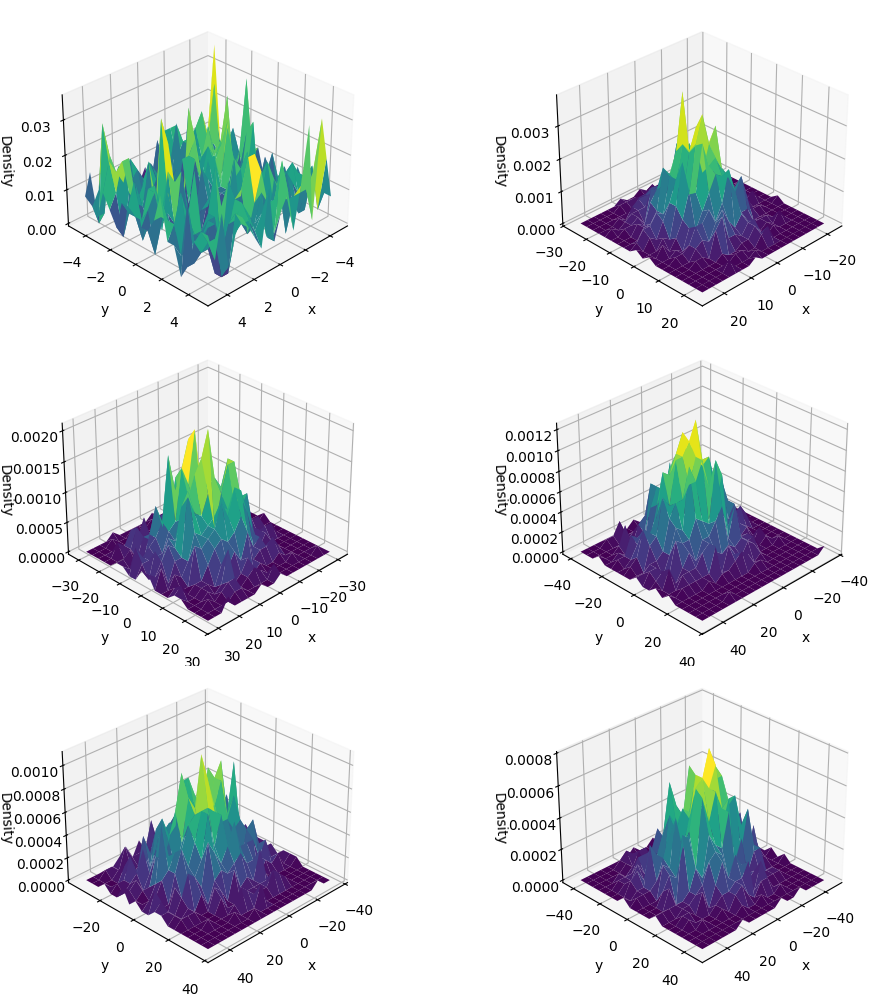

In [ ]:
time = [0, 100, 200, 300, 400, 500]
fig = plt.figure(figsize=(12, 10))
for i in range(6):
    ax = fig.add_subplot(3, 2, i+1, projection='3d')
    distribution_plot_3d(
        x_positions[time[i]],
        y_positions[time[i]],
    )
plt.tight_layout()
plt.show()

## Part 6 — Boundary Conditions in 2 dimension：

(1) Reflective boundary:

In [ ]:
def reflective_boundary_2d(x, y, L):
  x[x > L] = 2 * L - x[x > L]
  x[x < -L] = -2 * L - x[x < -L]
  y[y > L] = 2 * L - y[y > L]
  y[y < -L] = -2 * L - y[y < -L]
  return x, y

In [ ]:
L=50
x_positions, y_positions = random_walk_2d(N, T, L, reflective_boundary_2d)


### Plot 11 — Distribution of particle positions with reflective boundaries

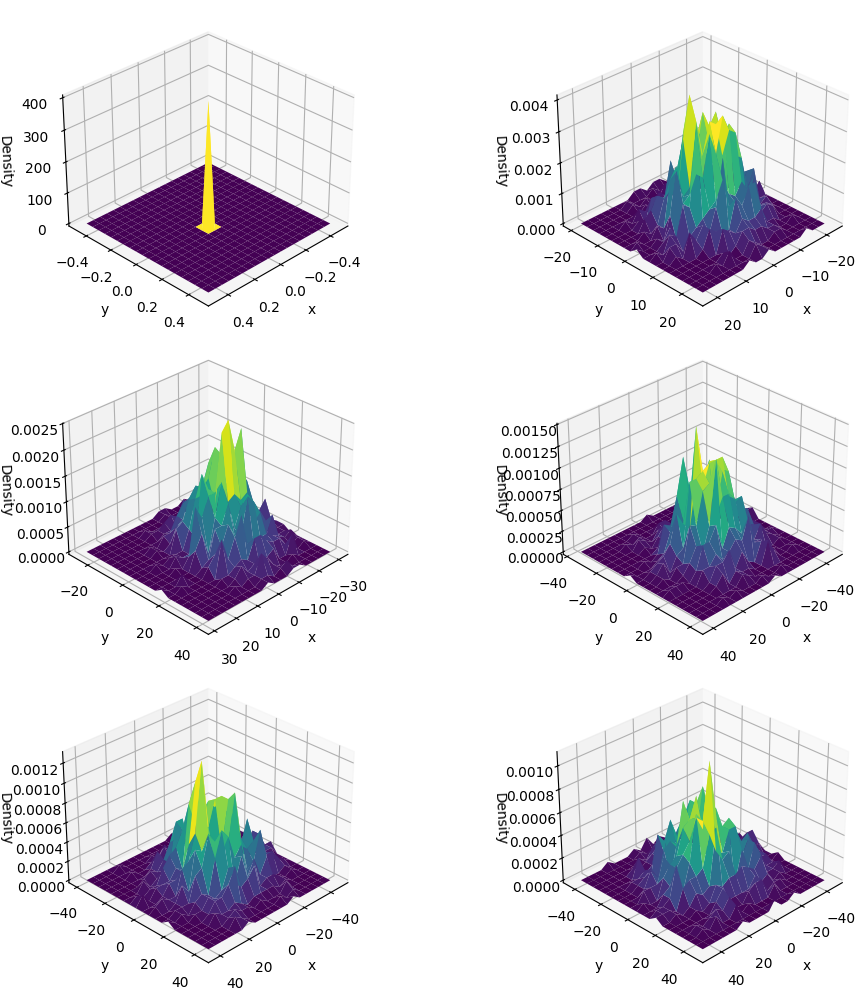

In [ ]:
time = [0, 100, 200, 300, 400, 500]
fig = plt.figure(figsize=(12, 10))
for i in range(6):
    ax = fig.add_subplot(3, 2, i+1, projection='3d')
    distribution_plot_3d(
        x_positions[time[i]],
        y_positions[time[i]],
    )
plt.tight_layout()
plt.show()

(2) Absorbing boundaries:


In [ ]:
def absorbing_boundary_2d(x, y, L):
    mask = (
        (x > L) | (x < -L) |
        (y > L) | (y < -L)
    )

    x[mask] = np.nan
    y[mask] = np.nan

    return x, y

In [ ]:
L=50
x_positions, y_positions = random_walk_2d(N, T, L, absorbing_boundary_2d)


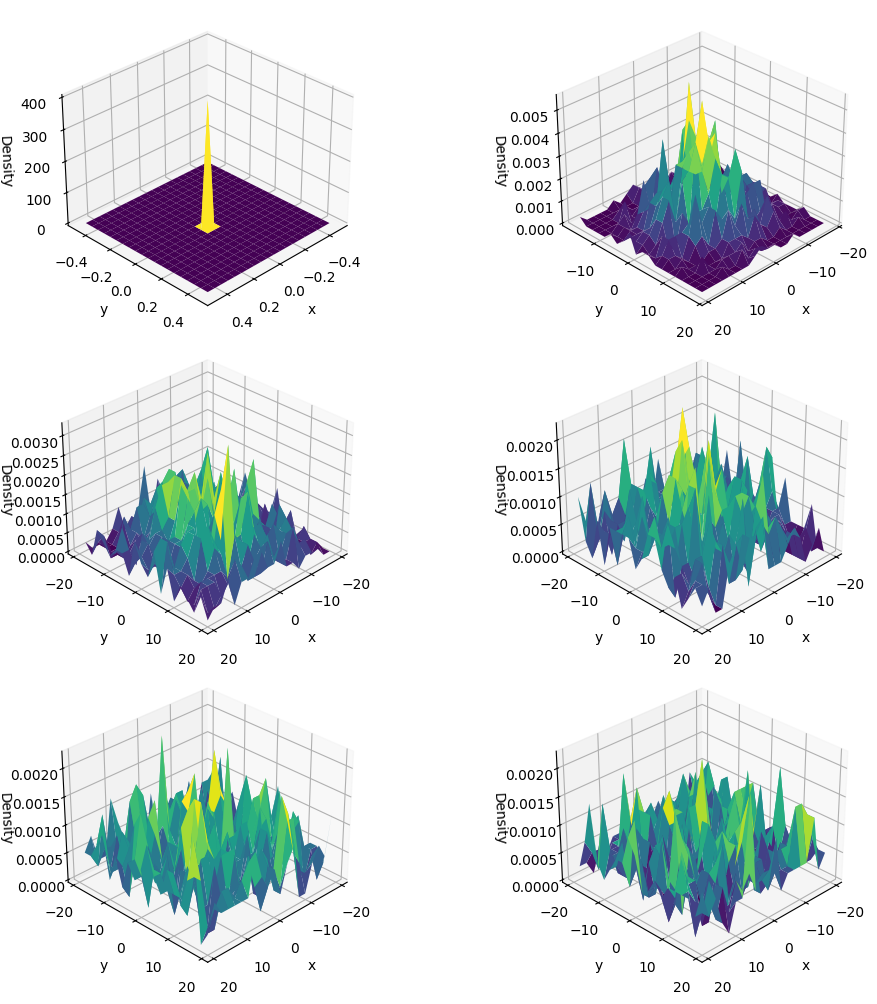

In [ ]:
time = [0, 100, 200, 300, 400, 500]
fig = plt.figure(figsize=(12, 10))
for i in range(6):
    ax = fig.add_subplot(3, 2, i+1, projection='3d')
    distribution_plot_3d(
        x_positions[time[i]],
        y_positions[time[i]],
    )
plt.tight_layout()
plt.show()

### Plot 12 - alive praticles in 2D

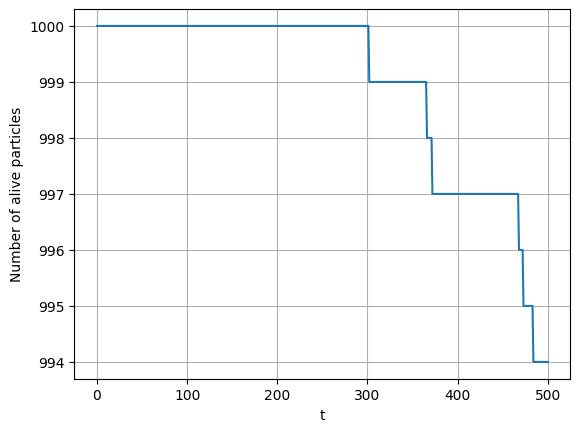

In [ ]:
alives = []

for t in range(T+1):
    alive = np.sum(
        (~np.isnan(x_positions[t])) &
        (~np.isnan(y_positions[t]))
    )
    alives.append(alive)

plt.figure()
plt.plot(range(T+1), alives)
plt.xlabel("t")
plt.ylabel("Number of alive particles")
plt.grid()
plt.show()

In [ ]:
def periodic_boundary_2d(x, y, L):
  x[x > L] = x[x > L] - 2 * L
  x[x < -L] = x[x < -L] + 2 * L
  y[y > L] = y[y > L] - 2 * L
  y[y < -L] = y[y < -L] + 2 * L
  return x,y

In [ ]:
L=20
x_positions, y_positions = random_walk_2d(N, T, L, periodic_boundary_2d)

### Plot - 13 trajectories of particles in periodic boundary

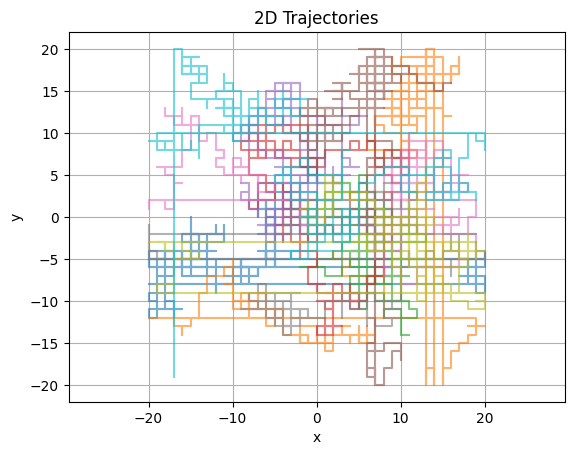

In [ ]:
plt.figure()
for i in range(10):
    plt.plot(x_positions[:, i], y_positions[:, i], alpha=0.6)

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Trajectories")
plt.grid()
plt.show()

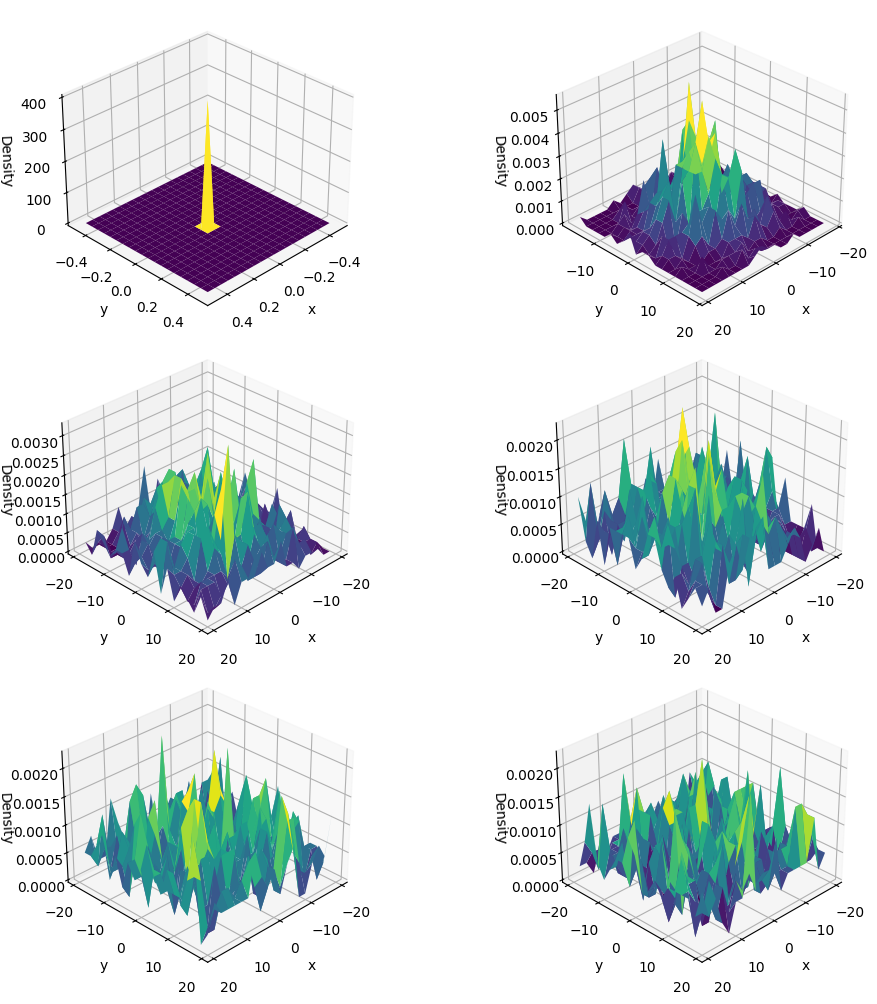

In [ ]:
time = [0, 100, 200, 300, 400, 500]
fig = plt.figure(figsize=(12, 10))
for i in range(6):
    ax = fig.add_subplot(3, 2, i+1, projection='3d')
    distribution_plot_3d(
        x_positions[time[i]],
        y_positions[time[i]],
    )
plt.tight_layout()
plt.show()
